# Tutorial 4 — Polynomial and Gaussian Basis Regression
**AIMS Ghana — Machine Learning Course, 2025**

---

## Overview

Two approaches to **non-linear regression**, both linear in their parameters:

1. **Polynomial regression** — monomial basis $\{1, x, x^2, \ldots, x^d\}$
2. **Gaussian RBF regression** — localised kernel basis

Both use the **Normal Equation**: $\hat{\theta} = (\Phi^T\Phi)^{-1}\Phi^T y$


## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 2. Part A — Polynomial Regression on a Small Dataset

We start with a small 8-point dataset.


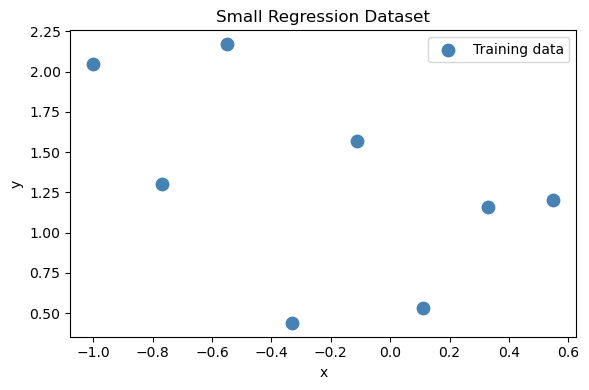

In [2]:
xi      = np.array([-1, -0.77, -0.55, -0.33, -0.11, 0.11, 0.33, 0.55])
yi      = np.array([2.05,  1.3,  2.17,  0.44,  1.57,  0.53,  1.16,  1.2])
x_test  = np.array([0.77, 1.0])

plt.figure(figsize=(6, 4))
plt.scatter(xi, yi, s=80, color='steelblue', zorder=5, label='Training data')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Small Regression Dataset'); plt.legend()
plt.tight_layout(); plt.show()


### Hypothesis and Design Matrix

The polynomial hypothesis function is:
$$\hat{y} = h(x; \theta) = X_{\text{poly}} \cdot \theta$$

where the design matrix is the **Vandermonde matrix** with increasing powers:
$$X_{\text{poly}} = \begin{pmatrix} 1 & x_1 & x_1^2 & \cdots & x_1^d \\\\ \vdots & & & & \vdots \\\\ 1 & x_m & x_m^2 & \cdots & x_m^d \end{pmatrix}$$


Design matrix shape: (8, 3)
Design matrix (first 3 rows):
 [[ 1.     -1.      1.    ]
 [ 1.     -0.77    0.5929]
 [ 1.     -0.55    0.3025]]

Theta (degree 2): [ 1.00204204 -0.18274363  0.85257897]


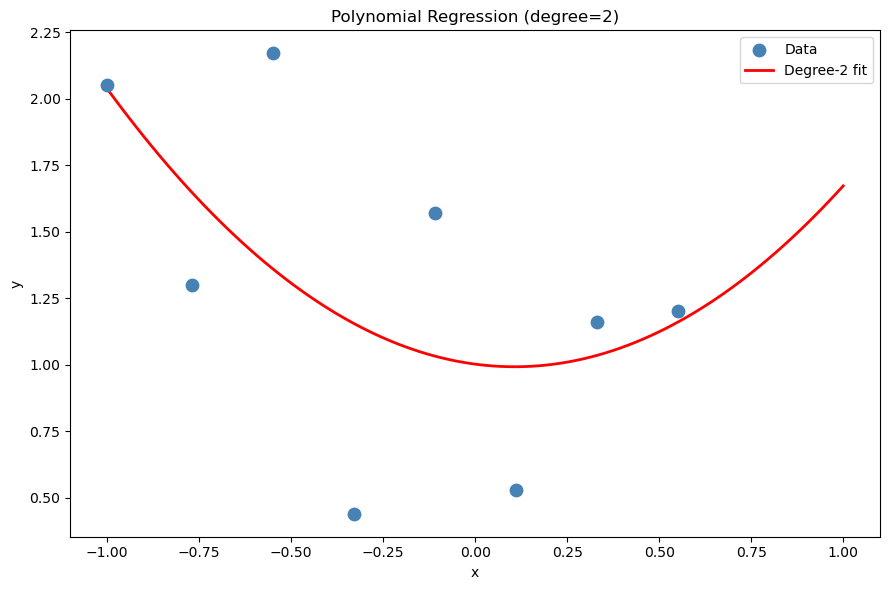

In [4]:
def poly_hyp(X, theta):
    """Polynomial hypothesis: ŷ = X @ theta"""
    return X.dot(theta)

def poly_design_matrix(x, degree):
    """Vandermonde design matrix with increasing powers [1, x, x^2, ..., x^d]."""
    return np.vander(x, N=degree + 1, increasing=True)

degree = 2
X_poly = poly_design_matrix(np.array(xi), degree)
print(f'Design matrix shape: {X_poly.shape}')
print('Design matrix (first 3 rows):\n', X_poly[:3])

# Fit via Normal Equation
theta_num = np.linalg.solve(X_poly.T @ X_poly, X_poly.T @ yi)
print('\nTheta (degree 2):', theta_num)

# Plot fit
x_plot     = np.linspace(-1, 1, 100)
X_plot_poly = poly_design_matrix(x_plot, degree)
y_plot      = poly_hyp(X_plot_poly, theta_num)

plt.figure(figsize=(9, 6))
plt.scatter(xi, yi, s=80, color='steelblue', zorder=5, label='Data')
plt.plot(x_plot, y_plot, 'r-', linewidth=2, label=f'Degree-{degree} fit')
plt.xlabel('x'); plt.ylabel('y')
plt.title(f'Polynomial Regression (degree={degree})')
plt.legend(); plt.tight_layout(); plt.show()


In [5]:
# Prediction on test set
X_test_poly  = poly_design_matrix(x_test, degree)
y_pred_test  = poly_hyp(X_test_poly, theta_num)
print('Predictions on test set:')
for xv, yv in zip(x_test, y_pred_test):
    print(f'  x = {xv:.2f}  →  ŷ = {yv:.4f}')


Predictions on test set:
  x = 0.77  →  ŷ = 1.3668
  x = 1.00  →  ŷ = 1.6719


## 3. Part B — Polynomial Regression on a Larger Dataset

We now load a larger dataset from `data.out` and explore multiple polynomial degrees.

> ⚠️ **Bug fixed:** The original notebook used `x_test` (defined only in Part A) when predicting on the `data.out` dataset. Here we define a proper `x_test_B` for Part B.


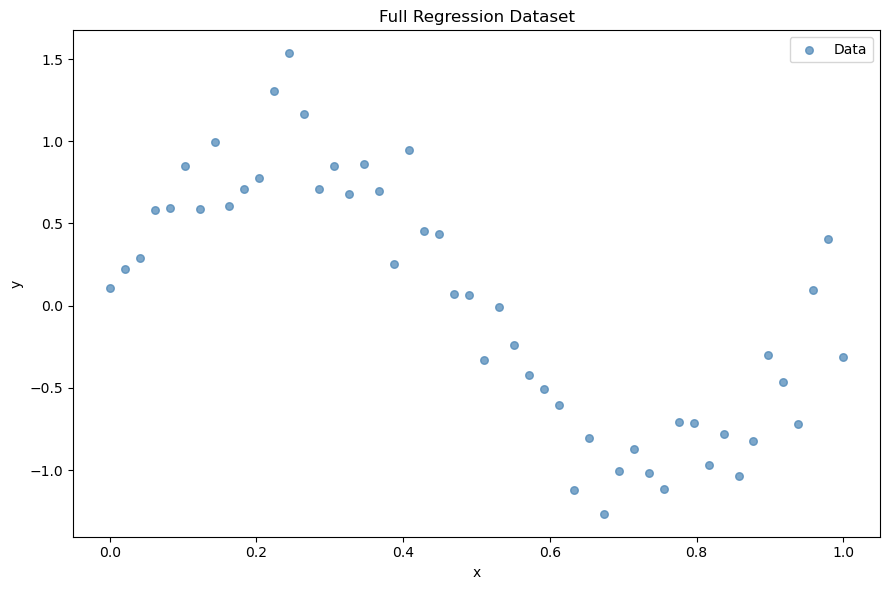

Dataset: 50 points  |  x ∈ [0.00, 1.00]


In [7]:
data  = np.loadtxt('data/data.out', delimiter=' ')
xi    = data[:, 0]
yi    = data[:, 1]

plt.figure(figsize=(9, 6))
plt.scatter(xi, yi, s=30, color='steelblue', alpha=0.7, label='Data')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Full Regression Dataset')
plt.legend(); plt.tight_layout(); plt.show()
print(f'Dataset: {len(xi)} points  |  x ∈ [{xi.min():.2f}, {xi.max():.2f}]')


Theta from Normal Equation: [ -0.09203878  11.89666887 -36.01102849  24.72570845]


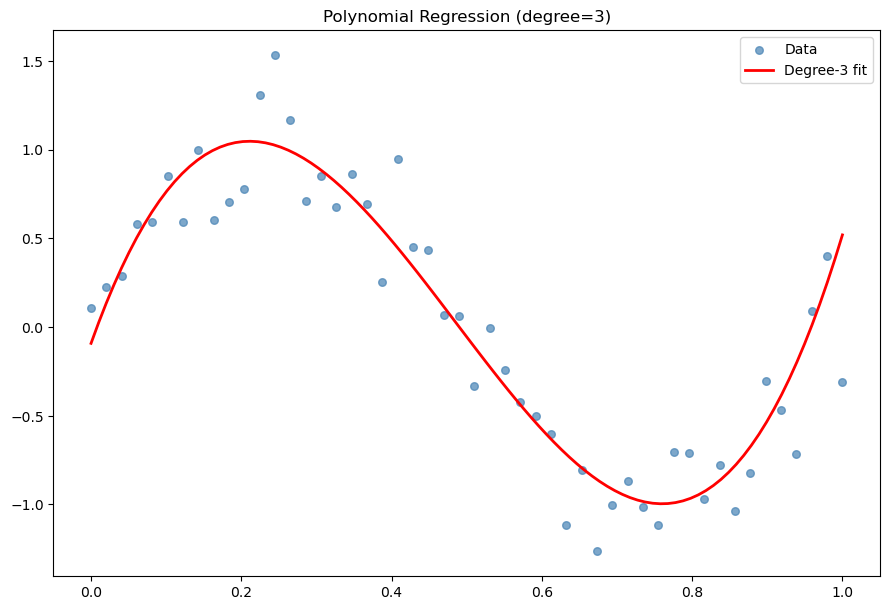


Predictions on test set: [-0.38688643 -0.2036116   0.0076721   0.24822565  0.51931005]


In [9]:
# Part B test set — last 10% of data
n_test   = max(2, len(xi) // 10)
x_test_B = xi[-n_test:]          # FIX: defined specifically for Part B
y_test_B = yi[-n_test:]

degree = 3
X_poly  = poly_design_matrix(np.array(xi[:-n_test]), degree)
theta_num = np.linalg.solve(X_poly.T @ X_poly, X_poly.T @ yi[:-n_test])
print('Theta from Normal Equation:', theta_num)

# Plot
x_plot     = np.linspace(xi.min(), xi.max(), 100)
X_plot_poly = poly_design_matrix(x_plot, degree)
y_plot      = poly_hyp(X_plot_poly, theta_num)

plt.figure(figsize=(9, 6))
plt.scatter(xi, yi, s=30, color='steelblue', alpha=0.7, label='Data')
plt.plot(x_plot, y_plot, 'r-', linewidth=2, label=f'Degree-{degree} fit')
plt.legend(); plt.tight_layout()
plt.title(f'Polynomial Regression (degree={degree})')
plt.show()

# Prediction on Part B test set
X_test_poly_B = poly_design_matrix(x_test_B, degree)
y_pred_B      = poly_hyp(X_test_poly_B, theta_num)
print('\nPredictions on test set:', y_pred_B)


## 4. Gaussian Process Regression (RBF Basis)

We use **Radial Basis Functions (RBF)** with $K$ randomly placed centres $\\mu_j$:

$$\phi_j(x) = \exp\!\left(-\frac{(x - \mu_j)^2}{2\sigma^2}\right)$$

The design matrix is $\Phi \in \mathbb{R}^{m \times K}$.

> ⚠️ **Bug fixed:** The original code stored the centres in `u` but never used them for prediction on a fine grid — it could only predict on training points.
> We now define `rbf_design_matrix(x, centres, sigma)` so we can predict anywhere.


In [10]:
sigma = 3.0
np.random.seed(42)
u = np.random.uniform(xi.min(), xi.max(), 4)   # 4 RBF centres
print('RBF centres:', u)

def rbf(x, mu, sigma):
    """Gaussian RBF: exp(-0.5 * ((x - mu) / sigma)^2)"""
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def rbf_design_matrix(x, centres, sigma):
    """
    RBF design matrix for arbitrary input x.
    Shape: (len(x), len(centres))

    FIX: accepts any x array, not just training points.
    This allows prediction on a fine plot grid.
    """
    X = np.zeros((len(x), len(centres)))
    for i, center in enumerate(centres):
        X[:, i] = rbf(x, center, sigma)
    return X

# Build design matrix on training data and fit
X_rbf    = rbf_design_matrix(xi, u, sigma)
theta_rbf = np.linalg.solve(X_rbf.T @ X_rbf, X_rbf.T @ yi)
print('RBF theta:', theta_rbf)


RBF centres: [0.37454012 0.95071431 0.73199394 0.59865848]
RBF theta: [-2143981.9197276   2255081.86038324 -9516806.99358436  9405811.66414575]


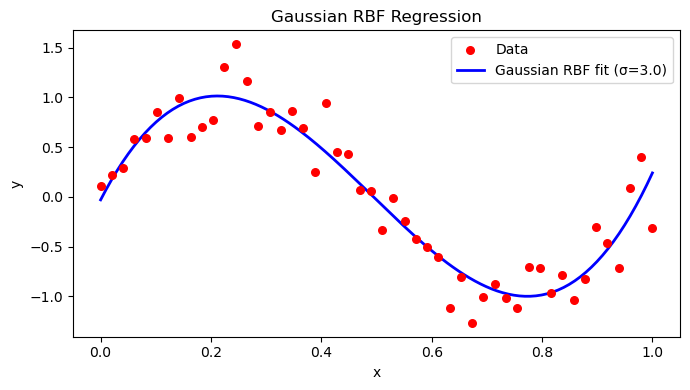

Training MSE: 0.0560


In [11]:
# FIX: predict on a fine grid for smooth curve
x_plot_rbf    = np.linspace(xi.min(), xi.max(), 200)
X_plot_rbf    = rbf_design_matrix(x_plot_rbf, u, sigma)   # FIX: use same centres u
f_plot        = X_plot_rbf @ theta_rbf

plt.figure(figsize=(7, 4))
plt.scatter(xi, yi, s=30, color='red', label='Data', zorder=5)
plt.plot(x_plot_rbf, f_plot, color='blue', linewidth=2,
         label=f'Gaussian RBF fit (σ={sigma})')
plt.title('Gaussian RBF Regression')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.tight_layout(); plt.show()

mse_rbf = np.mean((X_rbf @ theta_rbf - yi) ** 2)
print(f'Training MSE: {mse_rbf:.4f}')


**Interpretation:** The RBF model captures non-linear patterns through localised Gaussian bumps. The number and position of centres $u_j$ and the bandwidth $\\sigma$ control flexibility. More centres or smaller $\\sigma$ → more flexible model → potential overfitting.


## 5. Summary

| Method | Basis | Design Matrix Size | Smooth Curve? |
|---|---|---|---|
| Polynomial (degree d) | $\{1, x, \ldots, x^d\}$ | $(m \times (d+1))$ | ✅ |
| Gaussian RBF | $K$ Gaussian bumps | $(m \times K)$ | ✅ (after fix) |

Both remain **linear in parameters** → Normal Equation applies to both.
